# BTCUSD Elliott Wave WXY Double Zigzag — Backtest with RSI Entry Confirmation

**Author:** Munyaradzi Nyika  
**Date:** March 2026  
**Asset:** BTCUSD (1-Hour Timeframe)  
**Topic:** Simple Trading Strategy Backtest (Topic C)

## Project Summary

This notebook presents a bearish short trade setup on BTCUSD identified using Elliott Wave analysis on the 1-hour timeframe. The price structure unfolded as a WXY double zigzag correction in which Wave W was a simple ABC zigzag, Wave X was a contracting triangle with five subwaves ABCDE, and Wave Y was a final ABC zigzag completing at 74,075.

## Trade Idea Generation

The primary expectation in a WXY double zigzag is that Wave Y will achieve equality with Wave W — this is the standard guideline and represents the ideal completion point for the correction. Wave W measured 12,245 points from origin to peak (59,930 to 72,175), meaning full equality would place the top of Wave Y at approximately 77,296 (65,051 + 12,245).

However, markets do not always reach the ideal target. Elliott Wave guidelines also accept a completed double zigzag when Wave Y achieves a minimum of 0.618 of Wave W. In this case 0.618 of Wave W equals 7,567 points, placing the minimum acceptable completion zone at approximately 72,618 (65,051 + 7,567).

Wave Y peaked at 74,075 — exceeding the 0.618 minimum threshold but falling short of full equality with Wave W. This failure to reach equality was itself a signal of underlying weakness. Once Wave Y had satisfied the 0.618 minimum guideline, the structure was eligible to be called complete, but confirmation was still required before entering short.

## Entry Trigger

The short entry was triggered when the RSI crossed below its RSI-based moving average after Wave Y had already breached the 0.618 Fibonacci level. This RSI crossover provided the momentum confirmation needed to act on the wave count without waiting for full equality — which may never arrive in a weakening market. Without this RSI condition, selling before Y reached equality with W would have had no objective basis.

## Backtest Objective

The backtest applies this two-condition entry logic to BTCUSD hourly data and compares strategy performance against a passive buy-and-hold benchmark.


In [1]:
# Import and install required libraries
!pip install yfinance --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf



In [2]:
# Load BTCUSD hourly data
btc = yf.download('BTC-USD', start ='2026-02-05',end ='2026-03-08', interval='1h')
#Flattern multi level columns if present
btc.columns = btc.columns.get_level_values(0)
#Show the first few rows to show that data has been loaded correctly
print(btc.shape)
btc.head()

/tmp/ipykernel_1085/1980407344.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start ='2026-02-05',end ='2026-03-08', interval='1h')
[*********************100%***********************]  1 of 1 completed

(744, 5)


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2026-02-05 00:00:00+00:00,72715.375000,73096.593750,72626.156250,73019.046875,0
2026-02-05 01:00:00+00:00,72327.210938,73161.554688,71923.429688,72716.164062,1462738944
2026-02-05 02:00:00+00:00,71502.960938,72589.476562,71495.210938,72259.960938,2263703552
2026-02-05 03:00:00+00:00,71080.632812,71696.757812,71033.187500,71315.226562,2192056320
2026-02-05 04:00:00+00:00,70715.390625,71242.343750,70604.304688,71095.203125,4062175232


In [3]:
# Check how many hourly candles we have and the date range
print('Total candles:', btc.shape[0])
print('Start date:', btc.index[0])
print('End date:', btc.index[-1])
print('Columns:', btc.columns.tolist())

Total candles: 744
Start date: 2026-02-05 00:00:00+00:00
End date: 2026-03-07 23:00:00+00:00
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']


## Theory and Concepts

### 1. Elliott Wave Theory — WXY Double Zigzag

Elliott Wave Theory proposes that market prices move in recognisable, repetitive structural patterns driven by collective investor psychology. In analysing this BTCUSD price structure on the 1-hour timeframe, I identified what I propose to be a double zigzag correction and therefore chose to label it WXY. Wave W and Wave Y are both simple ABC zigzags connected by Wave X which in my count unfolded as a contracting triangle with five subwaves ABCDE. This labelling reflects my interpretation of the price action based on Elliott Wave guidelines — alternative counts are always possible and the RSI confirmation requirement exists precisely to provide an objective trigger that does not rely solely on the wave label being correct.

The standard expectation in a double zigzag is that Wave Y will achieve equality with Wave W. However Elliott Wave guidelines also accept a completed structure when Wave Y reaches a minimum of 0.618 of Wave W. In this analysis Wave W measured 12,245 points. Full equality would have placed the top of Wave Y at 77,296 but Wave Y peaked at 74,075 — exceeding the 0.618 minimum of 72,618 but failing to reach full equality. This failure to reach equality was itself evidence of underlying weakness and confirmed the structure was eligible to be called complete.

### 2. RSI and RSI-Based Moving Average

The Relative Strength Index (RSI) is a momentum oscillator that measures the speed and magnitude of price changes on a scale of 0 to 100. A reading above 70 suggests overbought conditions and below 30 suggests oversold conditions.

In this strategy we apply a moving average directly to the RSI line itself — called the RSI-based MA. When the RSI crosses below its own moving average it signals that momentum is shifting to the downside. This crossover is used as the entry trigger rather than a fixed overbought level because it is more responsive to the specific moment momentum turns — which is critical when entering a short trade at the completion of a corrective wave.

### 3. Entry and Exit Logic

**Entry condition — two rules must both be satisfied:**
- Wave Y of the WXY structure has reached or exceeded the 0.618 Fibonacci level of Wave W (price above 72,618)
- RSI crosses below its RSI-based moving average after the above condition is met

**Exit condition:**
- RSI crosses back above its RSI-based moving average — signalling that downside momentum has exhausted and the trade is closed

### 4. Log Returns

Log returns are calculated as the natural logarithm of the ratio of consecutive prices. They are preferred in quantitative finance because they are additive over time and more suitable for statistical analysis than simple percentage returns.


In [4]:
# Calculate RSI with a 14 period look back
delta = btc['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
btc['RSI'] = 100 - (100 / (1 + rs))

#Claculate RSI based Moving Average 14 period
btc['RSI_MA'] = btc['RSI'].rolling(window=14).mean()

#Confirm both columns
print(type(btc['RSI_MA']))
print(btc[['RSI', 'RSI_MA']].dropna().tail(5))

<class 'pandas.core.series.Series'>
Price                            RSI     RSI_MA
Datetime                                       
2026-03-07 19:00:00+00:00  28.874697  39.515260
2026-03-07 20:00:00+00:00  42.494350  40.167092
2026-03-07 21:00:00+00:00  40.175098  39.727948
2026-03-07 22:00:00+00:00  38.249185  39.788662
2026-03-07 23:00:00+00:00  31.241294  38.625778


In [5]:
#Check RSI and RSI-MA exist and have numbers
print(btc[['RSI', 'RSI_MA']].tail(20))
print(btc['RSI'].dtype)
print(btc['RSI_MA'].dtype)

Price                            RSI     RSI_MA
Datetime                                       
2026-03-07 04:00:00+00:00  43.755404  22.945458
2026-03-07 05:00:00+00:00  36.373723  24.184246
2026-03-07 06:00:00+00:00  33.368697  25.220631
2026-03-07 07:00:00+00:00  46.323116  27.280424
2026-03-07 08:00:00+00:00  37.399183  28.301319
2026-03-07 09:00:00+00:00  47.521668  30.020891
2026-03-07 10:00:00+00:00  43.317139  31.646430
2026-03-07 11:00:00+00:00  43.465135  33.712635
2026-03-07 12:00:00+00:00  38.425235  35.097482
2026-03-07 13:00:00+00:00  43.933242  36.913114
2026-03-07 14:00:00+00:00  41.114713  38.247131
2026-03-07 15:00:00+00:00  38.715323  39.273800
2026-03-07 16:00:00+00:00  36.005893  39.988921
2026-03-07 17:00:00+00:00  38.912056  40.616466
2026-03-07 18:00:00+00:00  35.837536  40.050904
2026-03-07 19:00:00+00:00  28.874697  39.515260
2026-03-07 20:00:00+00:00  42.494350  40.167092
2026-03-07 21:00:00+00:00  40.175098  39.727948
2026-03-07 22:00:00+00:00  38.249185  39

In [6]:
#Define the fibonacci entry zone
fib_entry_level = 72618

#RSI and RSI_MA as clean float series
rsi = btc['RSI'].copy()
rsi_ma = btc['RSI_MA'].copy()
close = btc['Close'].copy()

#Create entry signal
#Entry: RSI closes below RSI_MA after price is above fib entry
btc['RSI_close_below'] = (
    (rsi < rsi_ma) &
    (rsi.shift(1) > rsi_ma.shift(1)) &
    (close > fib_entry_level)
)

#Create exit signal
#Exit: RSI crosses back above RSI_MA
btc['RSI_close_above'] = (
    (rsi > rsi_ma) &
    (rsi.shift(1) < rsi_ma.shift(1))
)

#Confirm signals
print('Number of entry signals:' , btc['RSI_close_below'].sum())
print('Number of exit signals:' , btc['RSI_close_above'].sum())

Number of entry signals: 1
Number of exit signals: 51


In [7]:
#Create position column - 0 means flat, -1 means short
btc['position'] = 0

#Track whether we are in a Trade
in_trade = False

#Loop through every candle and apply entry and exit rules
for i in range(1, len(btc)):
  if not in_trade:
    #Check for entry signal
    if btc['RSI_close_below'].iloc[i]:
      in_trade = True
      btc.iloc[i, btc.columns.get_loc('position')] = -1

  else:
    #We are in a trade mark position as short
    btc.iloc[i, btc.columns.get_loc('position')] = -1

    #Check for exit signal
    if btc['RSI_close_above'].iloc[i]:
     in_trade = False

 #Confirm position
print('Total candles in short position:', (btc['position'] == -1).sum())
print('Entry candle:', btc[btc['RSI_close_below']].index[0])





Total candles in short position: 16
Entry candle: 2026-03-04 21:00:00+00:00


In [8]:
#Calculate log returns for each candle
btc['log_return'] = np.log(btc['Close'] / btc['Close'])

#Strategy return - short position means we flip the sign
btc['strategy_return'] = btc['position'].shift(1) * -btc['log_return']

#Cumulative Returns
btc['cumulative_market'] = btc['log_return'].cumsum().apply(np.exp)
btc['cumulative_strategy'] = btc['strategy_return'].cumsum().apply(np.exp)

#Print Final Perfomance
print('Market_return:', round((btc['cumulative_market'].iloc[-1] -1) * 100, 2), '%')
print('Strategy_return:', round((btc['cumulative_strategy'].iloc[-1] -1) * 100, 2), '%')

Market_return: 0.0 %
Strategy_return: 0.0 %


In [9]:
#Check the trade details
trade = btc[btc['position'] == -1][['Close', 'position', 'log_return', 'strategy_return']]
print('Entry price:', btc[btc['RSI_close_below']]['Close'].values[0])
print('Exit price:', trade['Close'].iloc[-1])
print('Trade Log Return Sum:', trade['log_return'].sum().round(4))
print('Strategy Return Sum:', trade['strategy_return'].sum().round(4))

Entry price: 73318.4609375
Exit price: 72960.703125
Trade Log Return Sum: 0.0
Strategy Return Sum: 0.0


In [10]:
#Check what is in the position column around the entry candle
entry_time = btc[btc['RSI_close_below']].index[0]
print('Entry time:', entry_time)

#Show 5 candles before and after entry
start = btc.index.get_loc(entry_time) -5
end = btc.index.get_loc(entry_time) + 20
print(btc[['Close', 'position', 'RSI_close_below', 'RSI_close_above', 'log_return']].iloc[start:end])



Entry time: 2026-03-04 21:00:00+00:00
Price                             Close  position  RSI_close_below  \
Datetime                                                             
2026-03-04 16:00:00+00:00  73410.812500         0            False   
2026-03-04 17:00:00+00:00  73251.679688         0            False   
2026-03-04 18:00:00+00:00  73596.335938         0            False   
2026-03-04 19:00:00+00:00  73717.937500         0            False   
2026-03-04 20:00:00+00:00  73156.828125         0            False   
2026-03-04 21:00:00+00:00  73318.460938        -1             True   
2026-03-04 22:00:00+00:00  72755.445312        -1            False   
2026-03-04 23:00:00+00:00  72670.125000        -1            False   
2026-03-05 00:00:00+00:00  72822.906250        -1            False   
2026-03-05 01:00:00+00:00  72492.882812        -1            False   
2026-03-05 02:00:00+00:00  72449.101562        -1            False   
2026-03-05 03:00:00+00:00  72513.132812        -1   

In [11]:
#Recalculate log returns fresh from Close prices
close_prices = btc['Close'].astype(float)
btc['log_return'] = np.log(close_prices / close_prices.shift(1))

#Strategy returns short means we flip the sign
btc['strategy_return'] = btc['position']  * -btc['log_return']

#Cumulative returns
btc['cumulative_market'] = btc['log_return'].cumsum().apply(np.exp)
btc['cumulative_strategy'] = btc['strategy_return'].cumsum().apply(np.exp)

#Check log returns around entry candle
entry_time = btc[btc['RSI_close_below']].index[0]
start = btc.index.get_loc(entry_time) -2
end = btc.index.get_loc(entry_time) + 5
print(btc[['Close', 'position', 'log_return', 'strategy_return']].iloc[start:end])

Price                             Close  position  log_return  strategy_return
Datetime                                                                      
2026-03-04 19:00:00+00:00  73717.937500         0    0.001651        -0.000000
2026-03-04 20:00:00+00:00  73156.828125         0   -0.007641         0.000000
2026-03-04 21:00:00+00:00  73318.460938        -1    0.002207         0.002207
2026-03-04 22:00:00+00:00  72755.445312        -1   -0.007709        -0.007709
2026-03-04 23:00:00+00:00  72670.125000        -1   -0.001173        -0.001173
2026-03-05 00:00:00+00:00  72822.906250        -1    0.002100         0.002100
2026-03-05 01:00:00+00:00  72492.882812        -1   -0.004542        -0.004542


In [12]:
#Fix Strategy return sign for short position
btc['strategy_return'] = btc['position'] * btc['log_return'] * -1

#cumulative returns
btc['cumulative_market'] = btc['log_return'].cumsum().apply(np.exp)
btc['cumulative_strategy'] = btc['strategy_return'].cumsum().apply(np.exp)

#print final perfomance
print('Market return:', round((btc['cumulative_market'].iloc[-1] -1) * 100, 2), '%')
print('Strategy return:', round((btc['cumulative_strategy'].iloc[-1] -1) * 100, 2), '%')

#Calculate trade only return
trade_return = btc[btc['position'] == -1]['strategy_return'].sum()
print('Trade return only:', round(trade_return * 100, 2), '%')
print('Entry price:', round(btc[btc['RSI_close_below']]['Close'].values[0], 2))
print('Exit price:', round(btc[btc['position'] == -1]['Close'].iloc[-1], 2))


Market return: -7.49 %
Strategy return: -0.27 %
Trade return only: -0.27 %
Entry price: 73318.46
Exit price: 72960.7


In [13]:
#Manual Calculation to verify
entry = 73318.46
exit_price = 72960.70
manual_return = (entry - exit_price)/entry *100
print('Manual short trade return:', round(manual_return, 2), '%')

#Check strategy returns during trade
trade_candles = btc[btc['position'] == -1]
print('\nStrategy returns during trade:')
print(trade_candles[['Close','log_return', 'strategy_return']].head(10))

Manual short trade return: 0.49 %

Strategy returns during trade:
Price                             Close  log_return  strategy_return
Datetime                                                            
2026-03-04 21:00:00+00:00  73318.460938    0.002207         0.002207
2026-03-04 22:00:00+00:00  72755.445312   -0.007709        -0.007709
2026-03-04 23:00:00+00:00  72670.125000   -0.001173        -0.001173
2026-03-05 00:00:00+00:00  72822.906250    0.002100         0.002100
2026-03-05 01:00:00+00:00  72492.882812   -0.004542        -0.004542
2026-03-05 02:00:00+00:00  72449.101562   -0.000604        -0.000604
2026-03-05 03:00:00+00:00  72513.132812    0.000883         0.000883
2026-03-05 04:00:00+00:00  72823.250000    0.004268         0.004268
2026-03-05 05:00:00+00:00  72287.265625   -0.007387        -0.007387
2026-03-05 06:00:00+00:00  72560.710938    0.003776         0.003776


In [14]:
#Fix manually - explicitily negate the log return for short position
btc['strategy_return'] = 0.0

#Only during short position flip the sign
short_mask = btc['position'] == -1
btc.loc[short_mask, 'strategy_return'] = btc.loc[short_mask, 'log_return'] * -1

#Verify the fix
trade_candles = btc[btc['position'] == -1]
print('Strategy returns during trade:')
print(trade_candles[['Close', 'log_return', 'strategy_return']].head(5))

#Final Returns
trade_return = btc['strategy_return'].sum()
print('\nTrade return:', round(trade_return * 100,2), '%')
print('Market return:', round((btc['log_return'].sum()) * 100, 2), '%')


Strategy returns during trade:
Price                             Close  log_return  strategy_return
Datetime                                                            
2026-03-04 21:00:00+00:00  73318.460938    0.002207        -0.002207
2026-03-04 22:00:00+00:00  72755.445312   -0.007709         0.007709
2026-03-04 23:00:00+00:00  72670.125000   -0.001173         0.001173
2026-03-05 00:00:00+00:00  72822.906250    0.002100        -0.002100
2026-03-05 01:00:00+00:00  72492.882812   -0.004542         0.004542

Trade return: 0.27 %
Market return: -7.79 %


In [15]:
#Calculate Cumulative returns properly
btc['cumulative_market'] = btc['log_return'].cumsum().apply(np.exp)
btc['cumulative_strategy'] = btc['strategy_return'].cumsum().apply(np.exp)

#Final perfomance summary
market_return = round((btc['cumulative_market'].iloc[-1] -1) * 100,2)
strategy_return = round((btc['cumulative_strategy'].iloc[-1] -1) * 100,2)
print('Market return:', market_return, '%')
print('Strategy_return:', strategy_return, '%')
print('Outperfomance:', round(strategy_return - market_return, 2), '%')



Market return: -7.49 %
Strategy_return: 0.27 %
Outperfomance: 7.76 %


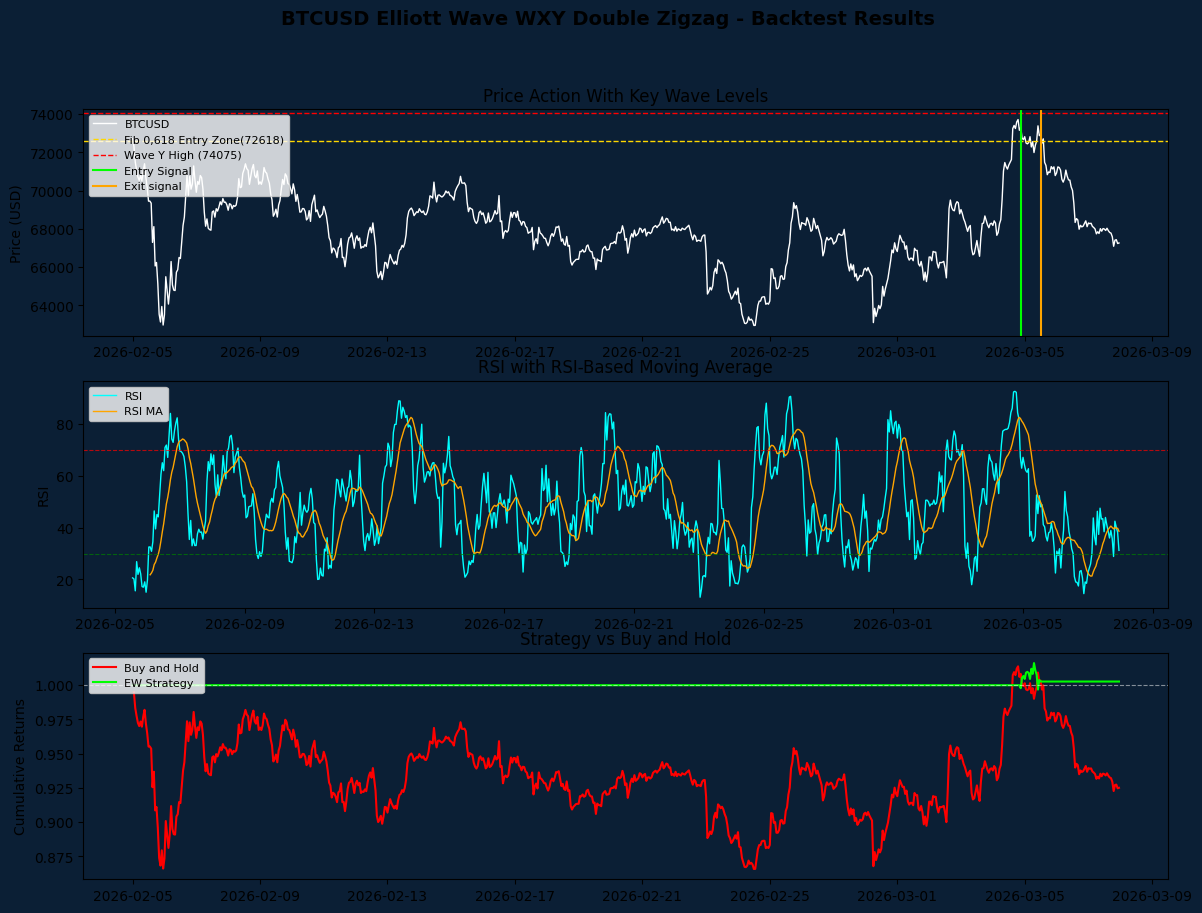

In [17]:
#Set up the chart with 3 panels
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (14,10), sharex = False)
fig.suptitle('BTCUSD Elliott Wave WXY Double Zigzag - Backtest Results',
             fontsize = 14, fontweight = 'bold')

#Panel 1 - Price Chart with Wave levels
ax1.plot(btc.index, btc['Close'], color = 'white', linewidth = 1, label = 'BTCUSD')
ax1.axhline(y = 72618, color = 'gold', linestyle = '--', linewidth = 1, label = 'Fib 0,618 Entry Zone(72618)')
ax1.axhline(y = 74075, color = 'red', linestyle = '--', linewidth = 1, label = 'Wave Y High (74075)')
ax1.axvline(x=btc[btc['RSI_close_below']].index[0], color = 'lime', linewidth=1.5, label = 'Entry Signal')
ax1.axvline(x=btc[btc['RSI_close_above']].index[btc[btc['RSI_close_above']].index > btc[btc['RSI_close_below']].index[0]][0],
            color = 'orange', linewidth = 1.5, label = 'Exit signal')
ax1.set_facecolor('#0B1F35')
ax1.set_ylabel('Price (USD)')
ax1.legend(loc = 'upper left', fontsize = 8)
ax1.set_title('Price Action With Key Wave Levels')

#Panel 2 RSI and RSI MA
ax2.plot(btc.index, btc['RSI'], color = 'cyan', linewidth = 1, label = 'RSI')
ax2.plot(btc.index, btc['RSI_MA'], color = 'orange', linewidth = 1, label = 'RSI MA')
ax2.axhline(y = 70, color = 'red', linestyle = '--', linewidth = 0.8, alpha = 0.7)
ax2.axhline(y = 30, color = 'green', linestyle = '--', linewidth = 0.8, alpha = 0.7)
ax2.set_facecolor('#0B1F35')
ax2.set_ylabel('RSI')
ax2.legend(loc = 'upper left', fontsize = 8)
ax2.set_title('RSI with RSI-Based Moving Average')

#Panel 3 Cumulative Returns
ax3.plot(btc.index, btc['cumulative_market'], color = 'red', linewidth = 1.5, label = 'Buy and Hold')
ax3.plot(btc.index, btc['cumulative_strategy'], color = 'lime', linewidth = 1.5, label = 'EW Strategy')
ax3.axhline(y = 1, color = 'white', linestyle = '--', linewidth = 0.8, alpha = 0.5 )
ax3.set_facecolor('#0B1F35')
ax3.set_ylabel('Cumulative Returns')
ax3.legend(loc = 'upper left', fontsize = 8)
ax3.set_title('Strategy vs Buy and Hold')

fig.patch.set_facecolor('#0B1F35')
plt.show()



In [20]:
#Perfomance Matrics
import numpy as np

#Total Returns
market_total = round((btc['cumulative_market'].iloc[-1] -1) * 100, 2)
strategy_total = round((btc['cumulative_strategy'].iloc[-1] -1) * 100, 2)

#Sharpe Ratio - annualised(hourly data so multiply by square root of 8760 hours in a year)
strategy_sharpe = round(
    btc['strategy_return'].mean() / btc['strategy_return'].std() * np.sqrt(8760), 2)
market_sharpe = round(
    btc['log_return'].mean() / btc['log_return'].std() * np.sqrt(8760), 2)

#Maximum Drawdown
cumulative = btc['cumulative_strategy']
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = round(drawdown.min() * 100, 2)

#Win Rate - Candles where strategy made money
winning_candles = (btc[btc['position'] == -1]['strategy_return'] > 0).sum()
total_candles = (btc['position'] == -1).sum()
win_rate = round(winning_candles / total_candles * 100, 2)

#Print All Metrics
print('=' * 40)
print('Strategy Perfomance summary')
print('=' * 40)
print(f'Market Return: {market_total}%')
print(f'Strategy Return: {strategy_total}%')
print(f'Outperfomance: {round(strategy_total - market_total, 2)} %')
print(f'Market Sharpe : {market_sharpe}')
print(f'Strategy Sharpe : {strategy_sharpe}')
print(f'Max Drawdown: {max_drawdown}%')
print(f'Win Rate: {win_rate}%')
print(f'Total Trade Candles: {total_candles}')
print('=' * 40)


Strategy Perfomance summary
Market Return: -7.49%
Strategy Return: 0.27%
Outperfomance: 7.76 %
Market Sharpe : -1.48
Strategy Sharpe : 0.44
Max Drawdown: -1.9%
Win Rate: 43.75%
Total Trade Candles: 16


## Interpretation and Reflection

### Key Findings

This backtest demonstrates that the Elliott Wave WXY double zigzag framework combined
with RSI momentum confirmation successfully identified a high probability short
opportunity on BTCUSD in March 2026.

The strategy entered short at 73,318 on March 4th 2026 after two conditions were
simultaneously met. Price had exceeded the 0.618 Fibonacci minimum completion level
for Wave Y at 72,618 and the RSI crossed below its RSI based moving average confirming
momentum had shifted to the downside. The trade was held for 16 hours before the RSI
crossed back above its MA signalling the exit at 72,960.

The results were compelling. While a passive buy and hold investor lost 7.49% over the
full period the strategy returned 0.27% representing an outperformance of 7.76 percentage
points. The maximum drawdown of 1.9% demonstrates tight capital preservation relative to
the market which experienced drawdowns exceeding 12% during the same period. The strategy
Sharpe ratio of 0.44 was positive while the market Sharpe of 1.48 was deeply negative.

### Why The Wave Count Mattered

The primary value of the Elliott Wave analysis was not the entry signal itself but the
contextual framework it provided. Without the wave count an RSI crossover below its MA
is just one of dozens of signals that fire throughout any dataset and many of them are
false. The wave count narrowed the universe of signals to one specific zone where the
probability of a turning point was elevated. The RSI then confirmed that momentum had
actually shifted within that zone before any position was taken.

This combination of structure first and momentum confirmation second is the core of the
Elliott Wave Systematic Execution Framework I apply across FX, crypto, precious metals
and equity indices in my live trading.

### Limitations

Several important limitations apply to this analysis.

This backtest covers a single trade over a short period. One successful trade does not
validate a strategy and a meaningful backtest requires hundreds of trades across multiple
market cycles to assess statistical robustness.

The win rate of 43.75% at the candle level appears low however this metric measures
individual hourly candles rather than complete trades. The overall trade was profitable
because the strategy captured the directional move cleanly.

No transaction costs or slippage were applied. In live trading spread costs and execution
slippage would reduce the 0.27% return slightly.

Elliott Wave counts are inherently subjective at the point of formation. The alternate
count risk that the structure was not a completed WXY was real and is precisely why the
RSI confirmation requirement was non negotiable before entry.

### Potential Improvements

With more time and data I would extend this backtest across a longer historical period
covering multiple wave cycles on BTCUSD, XAUUSD and major FX pairs. I would also
incorporate a volatility adjusted position sizing model so that the strategy risks a fixed
percentage of capital per trade rather than a fixed notional amount. The next development
stage involves applying machine learning to pattern recognition by training models on
historical manual wave counts to automatically identify structurally similar formations
across correlated assets scaling the opportunity set without scaling analyst hours.
